# 08 · Tolls and traffic counting

Sources: NHAI Datalake — `nh_network_of_india_new` (toll fee columns, unlabelled traffic columns) and `traffic_survey` (count locations); aggregates only (ADR-0014). Fee columns are mapped to vehicle classes and checked on every build against the National Highways Fee Rules, 2008 base-rate ratios (`config/fields/national_highways.yaml`).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

## Fee by vehicle class — does the column mapping hold?

In [2]:
pd.read_csv(A / "toll_fee_by_class.csv", index_col=0)

,median_fee_inr,median_ratio_to_car,fee_rule_ratio
fee_bus_truck,260.00,3.38,3.38
fee_car,75.00,1.00,1.00
fee_hcm_eme,410.00,5.29,5.31
fee_lcv,125.00,1.62,1.61
fee_oversized,485.00,6.42,6.46
fee_three_axle,315.00,3.75,3.69


## Tolled length, fees and traffic-count coverage by state

In [3]:
tt = pd.read_csv(A / "tolls_traffic_by_state.csv", index_col=0)
i = tt.loc["India"]
print(f"Tolled: {i.tolled_km:,.0f} of {i.nhai_nh_km:,.0f} km ({i.tolled_km_share:.1%}); median single-journey fee: car ₹{i.median_car_fee_inr:.0f}, bus/truck ₹{i.median_truck_fee_inr:.0f}. "
      f"Traffic counts on {i.traffic_count_km_share:.1%} of length; {i.traffic_survey_points:,.0f} confirmed count points ({i.survey_points_per_100_official_km:.1f} per 100 km).")
tt.round(3)

Tolled: 33,594 of 137,517 km (24.4%); median single-journey fee: car ₹75, bus/truck ₹260. Traffic counts on 52.7% of length; 4,179 confirmed count points (2.9 per 100 km).


,nhai_nh_km,tolled_km,tolled_km_share,stretches_with_fee,median_car_fee_inr,median_truck_fee_inr,traffic_count_km_share,traffic_survey_points,survey_points_per_100_official_km
state,,,,,,,,,
India,"137,516.98","33,594.14",0.24,"1,154.00",75.00,260.00,0.53,"4,179.00",2.86
Rajasthan,"10,279.19","5,508.68",0.54,111.00,75.00,260.00,0.12,258.00,2.40
Uttar Pradesh,"12,144.64","3,566.37",0.29,137.00,80.00,270.00,0.48,285.00,2.35
Madhya Pradesh,"9,019.42","3,183.60",0.35,84.00,95.00,330.00,0.46,226.00,2.47
Andhra Pradesh,"7,841.30","3,105.69",0.40,93.00,65.00,220.00,0.21,165.00,1.90
Tamil Nadu,"7,147.85","2,437.45",0.34,92.00,65.00,220.00,0.39,217.00,3.10
Maharashtra,"18,350.86","2,068.23",0.11,93.00,75.00,260.00,0.66,631.00,3.42
Karnataka,"7,646.06","2,057.19",0.27,72.00,67.50,227.50,0.47,330.00,4.03
Gujarat,"7,000.32","2,048.37",0.29,52.00,100.00,335.00,0.27,306.00,3.77


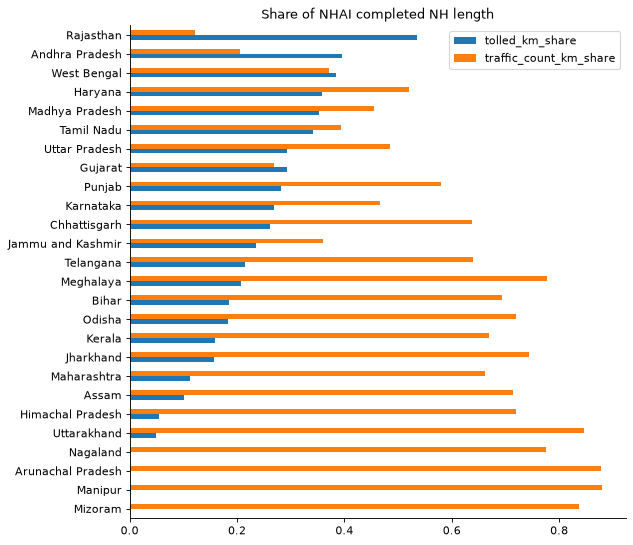

In [4]:
big = tt.drop("India").query("nhai_nh_km > 1000").sort_values("tolled_km_share")
ax = big.plot.barh(y=["tolled_km_share", "traffic_count_km_share"], figsize=(8, 8), title="Share of NHAI completed NH length")
ax.set_ylabel("");

## Traffic columns
`traffic_1` … `traffic_14` are counts by an unstated vehicle category; NHAI publishes no legend (layer metadata, lookup table and dashboard code checked on 2026-09-29), and no column equals a total. They are profiled here, not interpreted — no per-vehicle crash rates until NHAI supplies the legend.

In [5]:
net = nh.nhai_network()
cols = nh.CFG["traffic_columns"]
net.loc[net.has_traffic, cols].describe().T[["count", "50%", "max"]].round(0)

,count,50%,max
traffic_1,"3,069.00",647.00,"19,093.00"
traffic_2,"3,069.00",0.00,0.00
traffic_3,"3,069.00",95.00,"2,806.00"
traffic_4,"3,069.00",243.00,"5,096.00"
traffic_5,"3,069.00",4.00,"2,590.00"
traffic_6,"3,069.00",188.00,"6,306.00"
traffic_7,"3,069.00",1.00,126.00
traffic_8,"3,069.00",162.00,"9,632.00"
traffic_9,"3,069.00",0.00,20.00
traffic_10,"3,069.00","1,563.00","69,214.00"
